In [14]:
import numpy as np

def two_body_decay(M, m1, m2):
   
    term1 = M**2 - (m1 + m2)**2
    term2 = M**2 - (m1 - m2)**2
    p = np.sqrt(term1 * term2) / (2 * M)

    cos_theta = np.random.uniform(-1, 1)
    theta = np.arccos(cos_theta)
    phi = np.random.uniform(0, 2*np.pi)
    
    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * cos_theta

    p1 = np.array([px, py, pz])
    p2 = -p1

    E1 = np.sqrt(p**2 + m1**2)
    E2 = np.sqrt(p**2 + m2**2)

    return (E1, p1), (E2, p2)

def invariant_mass(E1, p1, E2, p2):
    E = E1 + E2
    p = p1 + p2
    return np.sqrt(E**2 - np.dot(p, p))


def expected_dedx(p, mass):
    beta = p / np.sqrt(p**2 + mass**2)
    return 1 / beta**2  # uproszczenie
def nsigma(measured, expected, sigma=0.05):
    return (measured - expected) / sigma

import matplotlib.pyplot as plt

def smear_momentum(p, resolution=0.05):
    """Symuluje rozdzielczość pędu detektora"""
    smear = np.random.normal(0, resolution)
    return p * (1 + smear)

M = 3.096  # GeV (J/psi)
m_mu = 0.105

N = 10000

masses = []
thetas = []
phis = []

for _ in range(N):
    (E1, p1), (E2, p2) = two_body_decay(M, m_mu, m_mu)

    p1_s = smear_momentum(p1)
    p2_s = smear_momentum(p2)

    E1_s = np.sqrt(np.dot(p1_s, p1_s) + m_mu**2)
    E2_s = np.sqrt(np.dot(p2_s, p2_s) + m_mu**2)

    m = invariant_mass(E1_s, p1_s, E2_s, p2_s)
    masses.append(m)

    p = np.linalg.norm(p1)
    theta = np.arccos(p1[2] / p)
    phi = np.arctan2(p1[1], p1[0])

    thetas.append(theta)
    phis.append(phi)


(array([  1.,   0.,   0.,   1.,   3.,   1.,   4.,   4.,   3.,   3.,   2.,
          3.,   5.,  10.,  10.,  13.,   8.,  14.,  19.,  23.,  18.,  41.,
         31.,  42.,  47.,  45.,  57.,  63.,  78.,  85.,  93., 121., 111.,
         96., 149., 184., 165., 195., 185., 196., 203., 230., 248., 259.,
        269., 286., 261., 269., 302., 301., 299., 259., 304., 266., 276.,
        281., 231., 250., 254., 237., 241., 210., 204., 195., 185., 189.,
        143., 140., 130., 112., 107.,  83., 105.,  78.,  70.,  50.,  44.,
         42.,  51.,  29.,  25.,  23.,  22.,  24.,  24.,  11.,  10.,  11.,
          2.,   4.,   6.,   4.,   4.,   0.,   2.,   2.,   0.,   1.,   1.,
          2.]),
 array([2.69093164, 2.69884652, 2.70676141, 2.7146763 , 2.72259118,
        2.73050607, 2.73842095, 2.74633584, 2.75425072, 2.76216561,
        2.77008049, 2.77799538, 2.78591026, 2.79382515, 2.80174003,
        2.80965492, 2.8175698 , 2.82548469, 2.83339958, 2.84131446,
        2.84922935, 2.85714423, 2.86505912, 2.

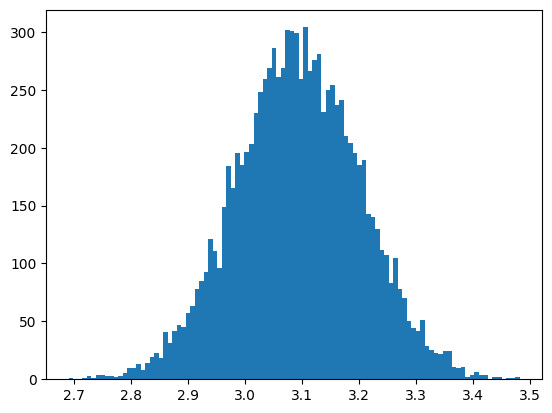

In [15]:
plt.hist(masses, bins=100)

In [16]:
import numpy as np

def bethe_bloch_like(p, m, K=1.0):
    """
    uproszczona krzywa BB (kształt realistyczny, nie absolutne jednostki)
    """
    E = np.sqrt(p**2 + m**2)
    beta = p / E

    # avoid divergence
    beta = np.clip(beta, 1e-6, 0.999999)

    # BB-like shape
    dedx = (1 / beta**2) * np.log(1 + beta**2 * 10)

    return K * dedx

In [17]:
def tpc_measurement(dedx_true, resolution=0.07):
    """
    symulacja rozdzielczości TPC (~5-10%)
    log-normal noise jak w realu
    """
    return dedx_true * np.exp(np.random.normal(0, resolution))

In [18]:
def nsigma_tpc(p, mass, dedx_meas, sigma=0.07):
    dedx_exp = bethe_bloch_like(p, mass)

    return (np.log(dedx_meas) - np.log(dedx_exp)) / sigma

In [19]:
masses = {
    "pi": 0.139,
    "K": 0.494,
    "p": 0.938
}

In [20]:
p = 1.0  # GeV

true_particle = "K"

dedx_true = bethe_bloch_like(p, masses[true_particle])
dedx_meas = tpc_measurement(dedx_true)

for name, m in masses.items():
    nsig = nsigma_tpc(p, m, dedx_meas)
    print(name, nsig)

pi 1.8457311182730258
K 0.11663869279148831
p -3.2469196060676375


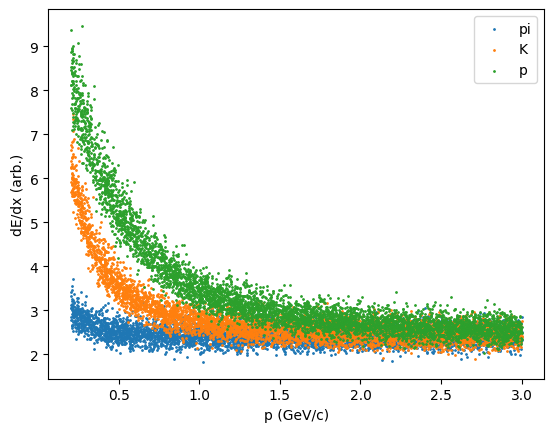

In [21]:
import matplotlib.pyplot as plt

N = 5000
ps = np.random.uniform(0.2, 3, N)

dedx_pi, dedx_K, dedx_p = [], [], []

for p in ps:
    dedx_pi.append(tpc_measurement(bethe_bloch_like(p, masses["pi"])))
    dedx_K.append(tpc_measurement(bethe_bloch_like(p, masses["K"])))
    dedx_p.append(tpc_measurement(bethe_bloch_like(p, masses["p"])))

plt.scatter(ps, dedx_pi, s=1, label="pi")
plt.scatter(ps, dedx_K, s=1, label="K")
plt.scatter(ps, dedx_p, s=1, label="p")

plt.xlabel("p (GeV/c)")
plt.ylabel("dE/dx (arb.)")
plt.legend()
plt.show()

In [22]:
masses = {
    "e": 0.000511,
    "mu": 0.105,
    "pi": 0.139,
    "K": 0.494,
    "p": 0.938
}

In [23]:
import numpy as np

def bethe_bloch_like(p, m):
    E = np.sqrt(p**2 + m**2)
    beta = p / E
    beta = np.clip(beta, 1e-6, 0.999999)

    return (1 / beta**2) * np.log(1 + 10 * beta**2)

In [24]:
def tpc_measurement(dedx, sigma=0.07):
    return dedx * np.exp(np.random.normal(0, sigma))

In [25]:
def nsigma(p, m, dedx_meas, sigma=0.07):
    dedx_exp = bethe_bloch_like(p, m)
    return (np.log(dedx_meas) - np.log(dedx_exp)) / sigma

In [26]:
def two_body_decay(M, m1, m2):
    term1 = M**2 - (m1 + m2)**2
    term2 = M**2 - (m1 - m2)**2
    p = np.sqrt(term1 * term2) / (2 * M)

    cos = np.random.uniform(-1, 1)
    phi = np.random.uniform(0, 2*np.pi)
    sin = np.sqrt(1 - cos**2)

    pvec = np.array([
        p * sin * np.cos(phi),
        p * sin * np.sin(phi),
        p * cos
    ])

    E1 = np.sqrt(p**2 + m1**2)
    E2 = np.sqrt(p**2 + m2**2)

    return (E1, pvec), (E2, -pvec)

In [27]:
def pid(p, dedx):
    results = {}

    for name, m in masses.items():
        results[name] = nsigma(p, m, dedx)

    return results

In [28]:
decays = {
    "Jpsi->ppbar": ("p", "p"),
    "Jpsi->mumu": ("mu", "mu"),
    "Jpsi->ee": ("e", "e"),
    "phi->KK": ("K", "K"),
    "psiprime->mumu": ("mu", "mu"),
    "gg->mumu": ("mu", "mu"),
    "gg->ee": ("e", "e"),
    "gg->KK": ("K", "K")
}

def simulate_decay(name, M):
    d1, d2 = decays[name]
    m1, m2 = masses[d1], masses[d2]

    (E1, p1), (E2, p2) = two_body_decay(M, m1, m2)

    # TPC measurement
    dedx1 = tpc_measurement(bethe_bloch_like(np.linalg.norm(p1), m1))
    dedx2 = tpc_measurement(bethe_bloch_like(np.linalg.norm(p2), m2))

    p = np.linalg.norm(p1)

    pid1 = pid(p, dedx1)
    pid2 = pid(p, dedx2)

    return pid1, pid2

In [29]:
M_Jpsi = 3.096

for i in range(5):
    pid1, pid2 = simulate_decay("Jpsi->mumu", M_Jpsi)
    print(pid1)

{'e': np.float64(-1.9431951907194804), 'mu': np.float64(-1.9840630799825658), 'pi': np.float64(-2.0146827237950453), 'K': np.float64(-2.799654281955388), 'p': np.float64(-4.64805350488946)}
{'e': np.float64(0.5025482299714762), 'mu': np.float64(0.46168034070839403), 'pi': np.float64(0.43106069689591137), 'K': np.float64(-0.35391086126443133), 'p': np.float64(-2.202310084198503)}
{'e': np.float64(0.03862551701337979), 'mu': np.float64(-0.0022423722497024096), 'pi': np.float64(-0.032862016062185084), 'K': np.float64(-0.8178335742225278), 'p': np.float64(-2.6662327971565993)}
{'e': np.float64(-1.2784784783493983), 'mu': np.float64(-1.3193463676124837), 'pi': np.float64(-1.3499660114249632), 'K': np.float64(-2.134937569585306), 'p': np.float64(-3.9833367925193777)}
{'e': np.float64(-1.975630889440197), 'mu': np.float64(-2.0164987787032826), 'pi': np.float64(-2.047118422515762), 'K': np.float64(-2.8320899806761046), 'p': np.float64(-4.680489203610176)}


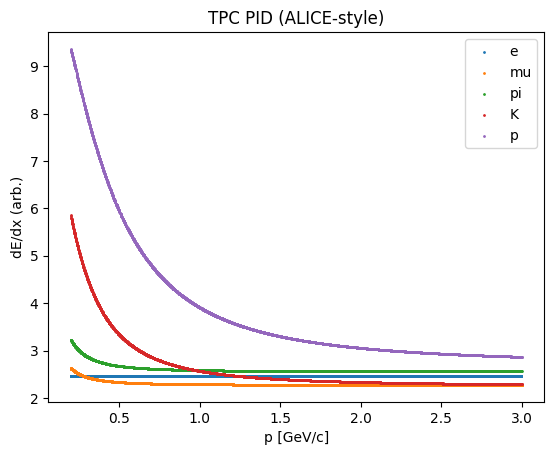

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def bethe_bloch_like(p, m):
    E = np.sqrt(p**2 + m**2)
    beta = p / E
    beta = np.clip(beta, 1e-6, 0.999999)
    return (1 / beta**2) * np.log(1 + 10 * beta**2)

masses = {
    "e": 0.000511,
    "mu": 0.105,
    "pi": 0.139,
    "K": 0.494,
    "p": 0.938
}

def tpc_measurement(dedx, sigma=0.07):
    return dedx * np.exp(np.random.normal(0, sigma))

N = 5000
plt.figure()

for name, m in masses.items():
    p = np.random.uniform(0.2, 3.0, N)
    dedx = bethe_bloch_like(p, m)
    dedx_meas = tpc_measurement(dedx)

    plt.scatter(p, dedx_meas, s=1, label=name)

plt.xlabel("p [GeV/c]")
plt.ylabel("dE/dx (arb.)")
plt.legend()
plt.title("TPC PID (ALICE-style)")
plt.show()

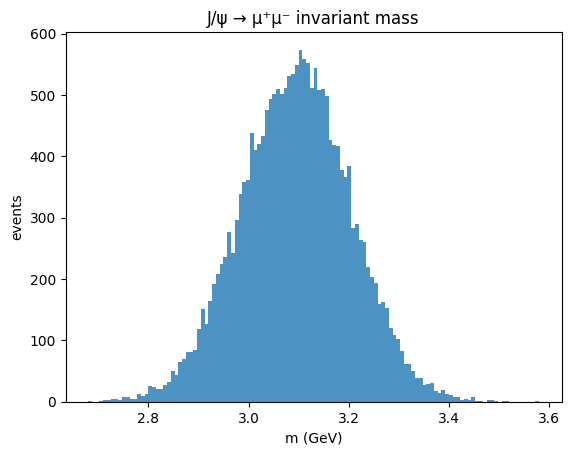

In [32]:
import numpy as np
import matplotlib.pyplot as plt

M_Jpsi = 3.096
m_mu = 0.105

masses_jpsi = []

for _ in range(20000):
    (E1, p1), (E2, p2) = two_body_decay(M_Jpsi, m_mu, m_mu)

    p1 = smear_momentum(p1)
    p2 = smear_momentum(p2)

    E1 = np.sqrt(np.dot(p1, p1) + m_mu**2)
    E2 = np.sqrt(np.dot(p2, p2) + m_mu**2)

    m = invariant_mass(E1, p1, E2, p2)
    masses_jpsi.append(m)

plt.hist(masses_jpsi, bins=120, alpha=0.8)
plt.xlabel("m (GeV)")
plt.ylabel("events")
plt.title("J/ψ → μ⁺μ⁻ invariant mass")
plt.show()

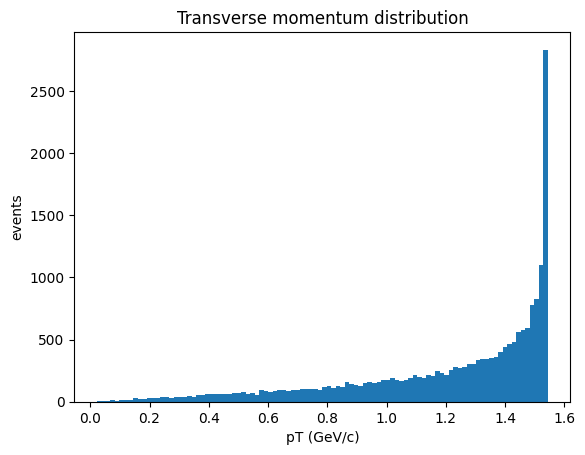

In [33]:
pT_vals = []

for _ in range(20000):
    (E1, p1), _ = two_body_decay(3.096, 0.105, 0.105)

    pT = np.sqrt(p1[0]**2 + p1[1]**2)
    pT_vals.append(pT)

plt.hist(pT_vals, bins=100)
plt.xlabel("pT (GeV/c)")
plt.ylabel("events")
plt.title("Transverse momentum distribution")
plt.show()

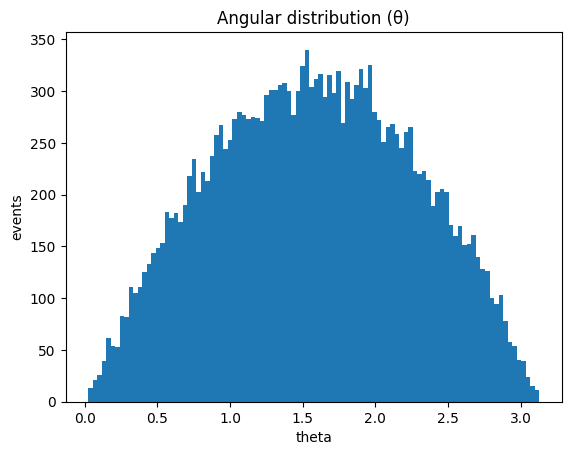

In [34]:
thetas = []
phis = []

for _ in range(20000):
    (E1, p1), _ = two_body_decay(3.096, 0.105, 0.105)

    p = np.linalg.norm(p1)
    theta = np.arccos(p1[2] / p)
    phi = np.arctan2(p1[1], p1[0])

    thetas.append(theta)
    phis.append(phi)

plt.hist(thetas, bins=100)
plt.xlabel("theta")
plt.ylabel("events")
plt.title("Angular distribution (θ)")
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def bethe_bloch(momentum, mass, charge=1):
    # Constants for Bethe-Bloch approximation
    K = 0.307075  # MeV mol^-1 cm^2
    Z = charge    # Particle charge
    I = 0.000016  # Mean excitation potential (MeV)
    m_e = 0.511   # Electron mass in MeV/c^2
    rho = 1       # Density of the material (relative to water)

    # Relativistic terms
    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)

    # Bethe-Bloch equation (simplified)
    dEdx = (
        ((K * Z**2 * rho) / (beta**2))
        * (0.5 * np.log(2 * m_e * beta**2 * gamma**2 / I**2) - beta**2)
    ) * 17

    return dEdx


def tpc_pid_response(momentum, particle_type, stretch_factor=1):
    mass_dict = {
        'electron': 0.000511,
        'muon': 0.10566,
        'pion': 0.13957,
        'kaon': 0.49367,
        'proton': 0.93827
    }

    mass = mass_dict.get(particle_type, 0.13957)  # Default pion
    dEdx = bethe_bloch(momentum, mass) * stretch_factor
    lower_band = dEdx * 0.7
    upper_band = dEdx * 1.3

    return dEdx, lower_band, upper_band


def error_extremes(momentum, particle_type, stretch_factor):
    _, lower_band, upper_band = tpc_pid_response(
        momentum, particle_type, stretch_factor
    )
    return upper_band, lower_band


def random_gaussian(mean, sigma):
    return np.random.normal(mean, sigma)


def gaussian_tpc_response(momentum, particle_type, stretch_factor):
    # Get mean dE/dx
    mean_dEdx, _, _ = tpc_pid_response(
        momentum, particle_type, stretch_factor
    )

    # Calculate 3σ band
    upper_band, lower_band = error_extremes(
        momentum, particle_type, stretch_factor
    )

    # Sigma estimate
    sigma_dEdx = (upper_band - lower_band) / 6

    # Random Gaussian value
    random_dEdx = random_gaussian(mean_dEdx, sigma_dEdx)

    return random_dEdx


# Example usage
momentum = 0.3
particle_type = 'proton'
x = 1000

rn = []

for _ in range(x):
    if particle_type == 'electron':
        stretch_factor = 1
    elif particle_type == 'muon':
        stretch_factor = 0.41
    elif particle_type == 'pion':
        stretch_factor = 0.41
    elif particle_type == 'kaon':
        stretch_factor = 0.38
    elif particle_type == 'proton':
        stretch_factor = 0.40

    random_value = gaussian_tpc_response(
        momentum, particle_type, stretch_factor
    )
    rn.append(random_value)

print(rn)

xvalues = []

for _ in range(x):
    xvalues.append(momentum)

print(xvalues)


def plot_tpc_pid_response(momentum_range):
    """
    Plot the TPC PID response and error bands
    for various particle types.
    """
    particle_types = {
        'Electron': {'color': 'blue', 'stretch_factor': 1},
        'Muon': {'color': 'orange', 'stretch_factor': 0.41},
        'Pion': {'color': 'red', 'stretch_factor': 0.41},
        'Kaon': {'color': 'green', 'stretch_factor': 0.38},
        'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }

    plt.figure(figsize=(8, 6))

    for particle, settings in particle_types.items():
        response, lower_band, upper_band = tpc_pid_response(
            momentum_range,
            particle.lower(),
            settings['stretch_factor']
        )

        plt.plot(
            momentum_range,
            response,
            label=particle,
            color=settings['color']
        )

        plt.fill_between(
            momentum_range,
            lower_band,
            upper_band,
            color=settings['color'],
            alpha=0.2
        )

    # plt.plot(xvalues, rn, color='black')

    plt.xlabel('Momentum (GeV/c)')
    plt.ylabel('dE/dx (arbitrary units)')
    plt.xscale('log')
    plt.yscale('log')
    plt.title('ALICE TPC PID Response with 3sigma Bands')
    plt.legend()
    plt.grid(True)
    plt.show()

[180.48918405208684, 226.897544410895, 174.94770358111515, 248.85164620845416, 226.83128187415767, 227.79613291518467, 222.8782422091498, 201.21848730275826, 198.96443354322253, 249.04511295881076, 206.92477867825002, 213.12664658236307, 209.87172870983142, 222.81642385794567, 211.92114687057, 216.85606622360967, 235.90645734690818, 199.98678204724743, 223.95893320650924, 251.9703971293659, 236.88956056163224, 192.88964832859594, 215.50341466074548, 229.79575385317906, 200.2773236305254, 246.5985043793884, 218.3406436691842, 254.22027560283576, 230.3866129460204, 206.52527081684812, 215.05812269475578, 222.93588331242168, 203.69052956045357, 243.41428284219174, 194.7943633831977, 201.69077101305135, 211.26737471424786, 237.98959827423624, 251.06076404135527, 254.03943736215754, 238.46683222734526, 209.36578638495956, 183.18005316359313, 239.86815079340118, 248.50115362125308, 208.99662006800295, 255.42491922136006, 218.84260572757455, 211.05853427989746, 220.6682489127577, 203.73654429

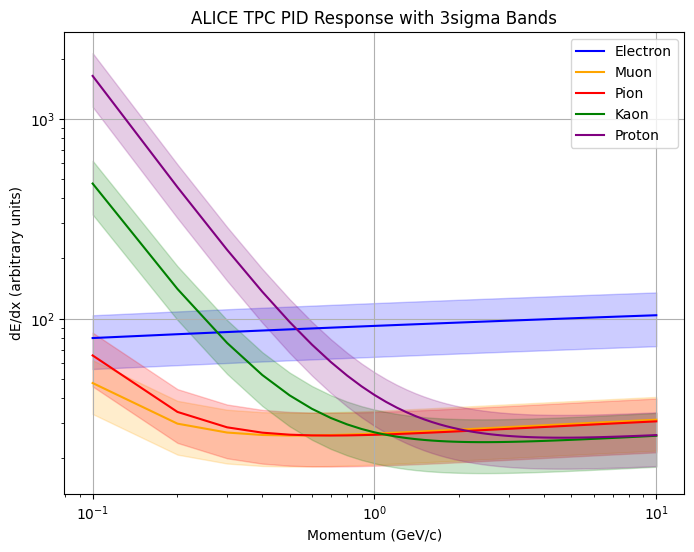

In [8]:
momentum_range = np.linspace(0.1, 10, 100) # Momentum range from 0.1 to 10 GeV/c
plot_tpc_pid_response(momentum_range)

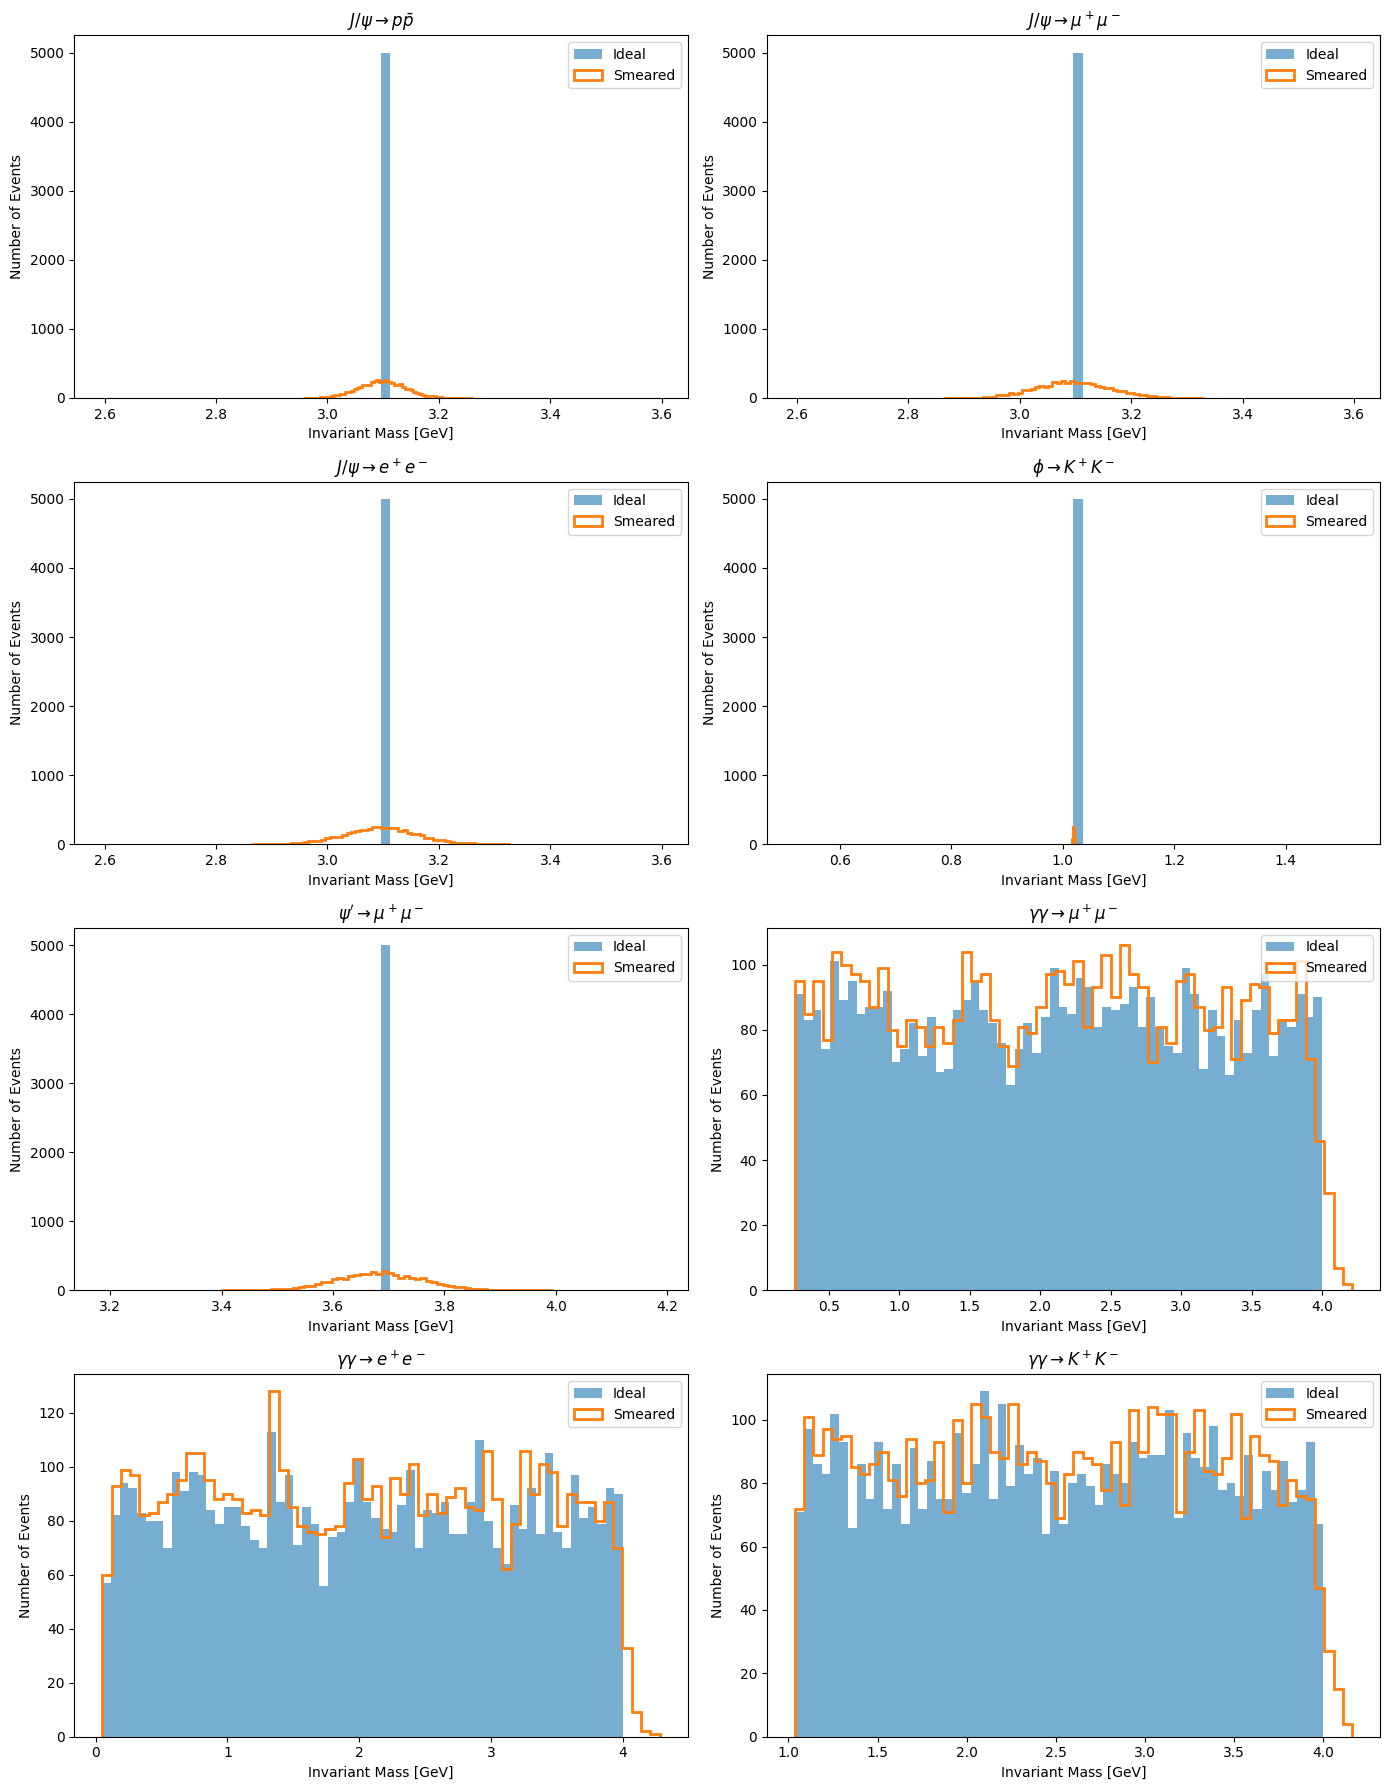

In [17]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# PARTICLE MASSES [GeV]
masses_dict = {
    "p": 0.938,
    "mu": 0.105,
    "e": 0.000511,
    "K": 0.494
}

# RESONANCES
resonances = {
    "J/psi": 3.096,
    "phi": 1.019,
    "psi'": 3.686
}
# FUNCTIONS

def two_body_decay(M, m1, m2):
    """
    Two-body decay in center-of-mass frame
    """
    term1 = M**2 - (m1 + m2)**2
    term2 = M**2 - (m1 - m2)**2
    p = np.sqrt(term1 * term2) / (2 * M)

    cos_theta = np.random.uniform(-1, 1)
    phi = np.random.uniform(0, 2*np.pi)

    sin_theta = np.sqrt(1 - cos_theta**2)

    px = p * sin_theta * np.cos(phi)
    py = p * sin_theta * np.sin(phi)
    pz = p * cos_theta

    p1 = np.array([px, py, pz])
    p2 = -p1

    E1 = np.sqrt(p**2 + m1**2)
    E2 = np.sqrt(p**2 + m2**2)

    return (E1, p1), (E2, p2)


def invariant_mass(E1, p1, E2, p2):
    """
    Calculate invariant mass
    """
    E = E1 + E2
    p = p1 + p2
    return np.sqrt(E**2 - np.dot(p, p))


def smear_vector(pvec, resolution=0.03):
    """
    Detector momentum smearing
    """
    factor = np.random.normal(1.0, resolution)
    return pvec * factor

# 8 PROCESSES

processes = {
    # Meson decays
    r"$J/\psi \to p\bar{p}$":
        ("resonance", "J/psi", "p", "p"),

    r"$J/\psi \to \mu^+\mu^-$":
        ("resonance", "J/psi", "mu", "mu"),

    r"$J/\psi \to e^+e^-$":
        ("resonance", "J/psi", "e", "e"),

    r"$\phi \to K^+K^-$":
        ("resonance", "phi", "K", "K"),

    r"$\psi' \to \mu^+\mu^-$":
        ("resonance", "psi'", "mu", "mu"),

    # Two-photon processes
    r"$\gamma\gamma \to \mu^+\mu^-$":
        ("continuum", None, "mu", "mu"),

    r"$\gamma\gamma \to e^+e^-$":
        ("continuum", None, "e", "e"),

    r"$\gamma\gamma \to K^+K^-$":
        ("continuum", None, "K", "K"),
}

# EVENT GENERATION

N = 5000

results_true = {}
results_smear = {}

for name, cfg in processes.items():

    mode = cfg[0]
    resonance = cfg[1]
    p1_name = cfg[2]
    p2_name = cfg[3]

    m1 = masses_dict[p1_name]
    m2 = masses_dict[p2_name]

    masses_true = []
    masses_s = []

    for _ in range(N):

        # Resonance peak
        if mode == "resonance":
            M = resonances[resonance]

        # Continuum gamma-gamma production
        else:
            M = np.random.uniform(m1 + m2 + 0.05, 4.0)

        (E1, p1), (E2, p2) = two_body_decay(M, m1, m2)

        # True invariant mass
        m_true = invariant_mass(E1, p1, E2, p2)

        # Smeared detector measurement
        p1s = smear_vector(p1)
        p2s = smear_vector(p2)

        E1s = np.sqrt(np.dot(p1s, p1s) + m1**2)
        E2s = np.sqrt(np.dot(p2s, p2s) + m2**2)

        m_s = invariant_mass(E1s, p1s, E2s, p2s)

        masses_true.append(m_true)
        masses_s.append(m_s)

    results_true[name] = masses_true
    results_smear[name] = masses_s

# PLOTS

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, name in enumerate(processes.keys()):

    ax = axes[i]

    ax.hist(results_true[name],
            bins=60,
            alpha=0.6,
            label="Ideal")

    ax.hist(results_smear[name],
            bins=60,
            histtype="step",
            linewidth=2,
            label="Smeared")

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Invariant Mass [GeV]")
    ax.set_ylabel("Number of Events")
    ax.legend()

plt.tight_layout()
plt.show()

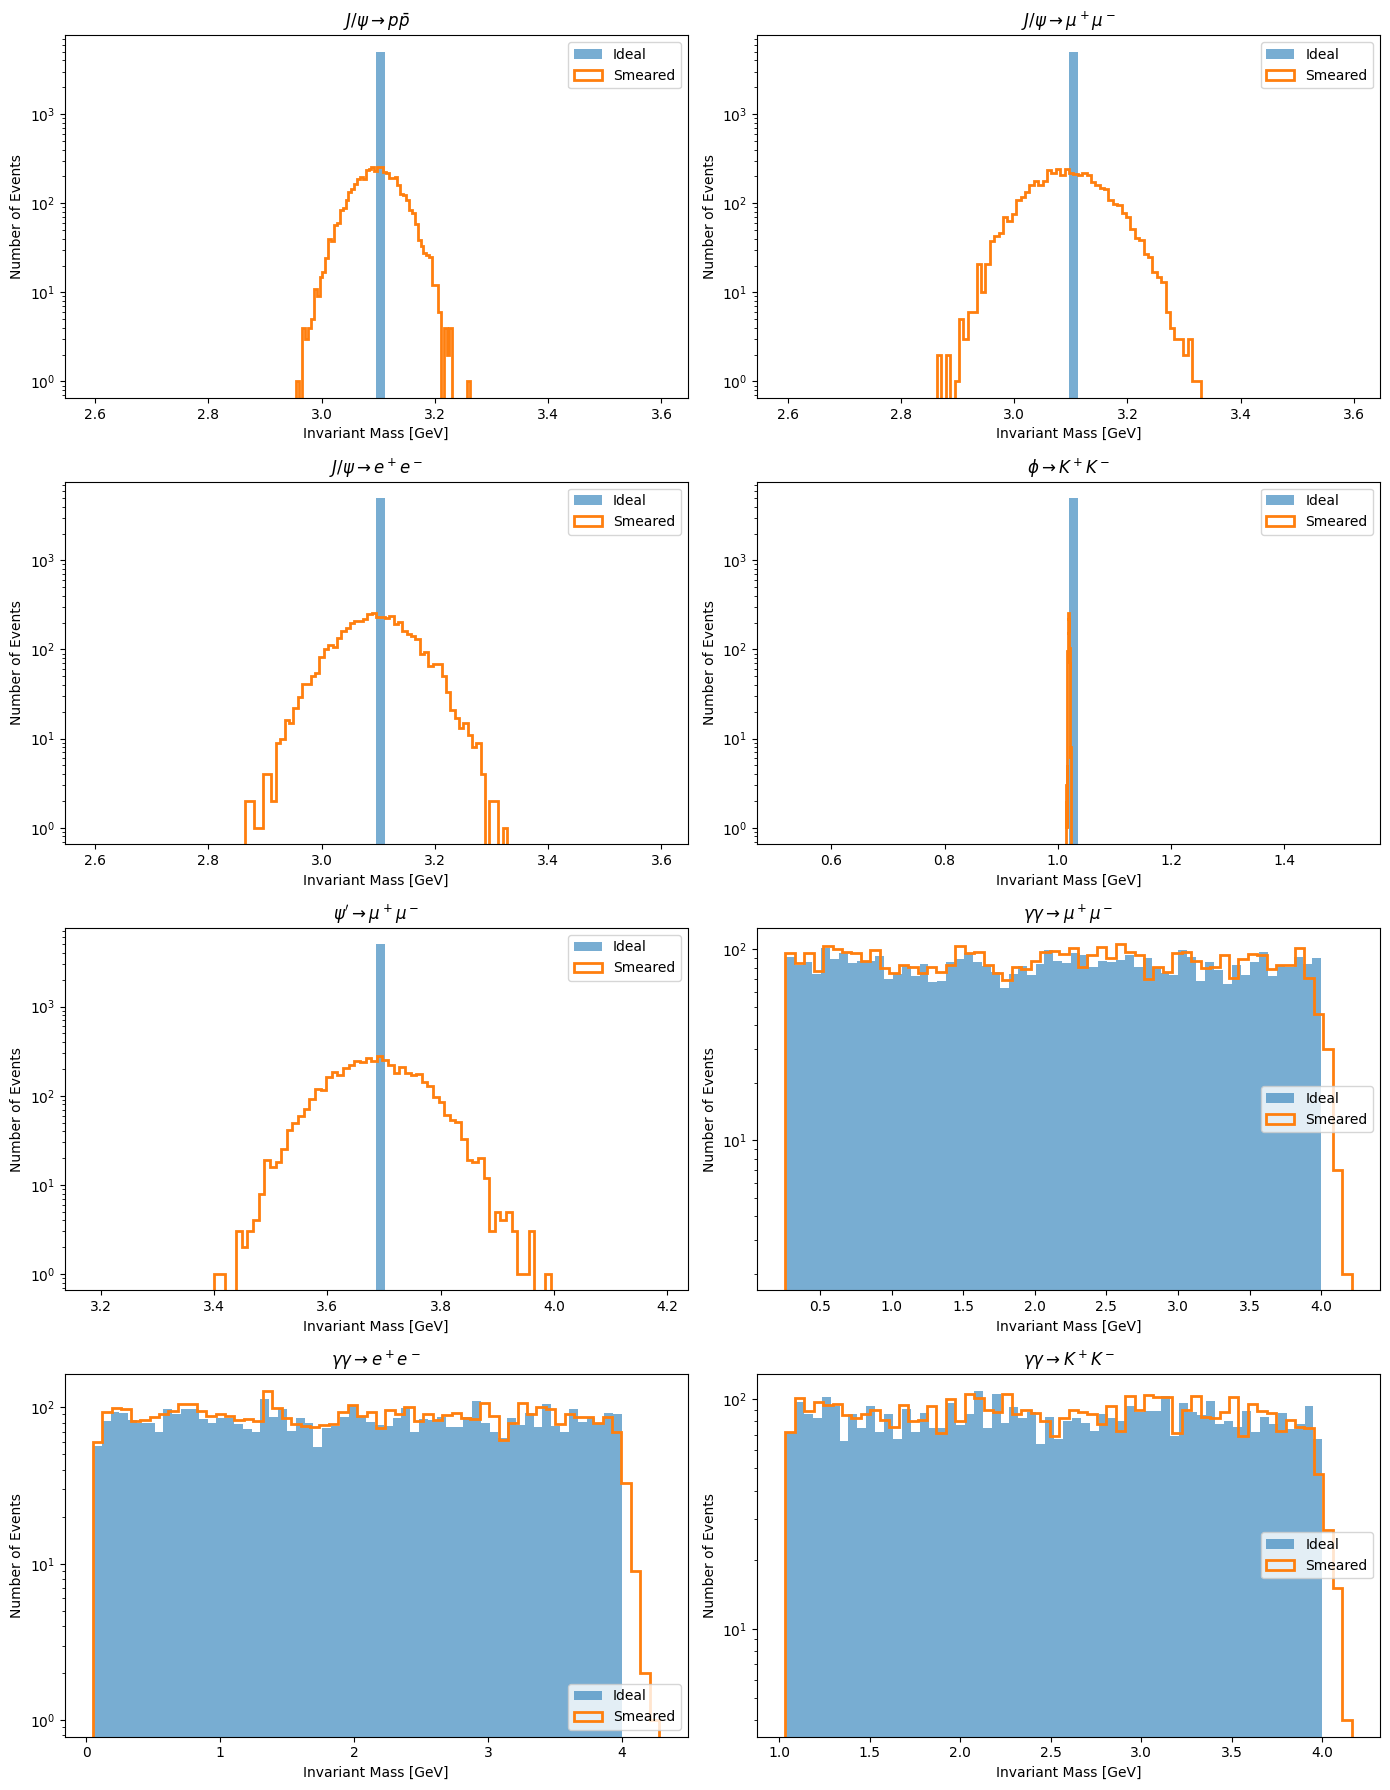

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, name in enumerate(processes.keys()):

    ax = axes[i]

    ax.hist(results_true[name],
            bins=60,
            alpha=0.6,
            label="Ideal")

    ax.hist(results_smear[name],
            bins=60,
            histtype="step",
            linewidth=2,
            label="Smeared")

    ax.set_yscale("log")   # logarithmic scale

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Invariant Mass [GeV]")
    ax.set_ylabel("Number of Events")
    ax.legend()

plt.tight_layout()
plt.show()

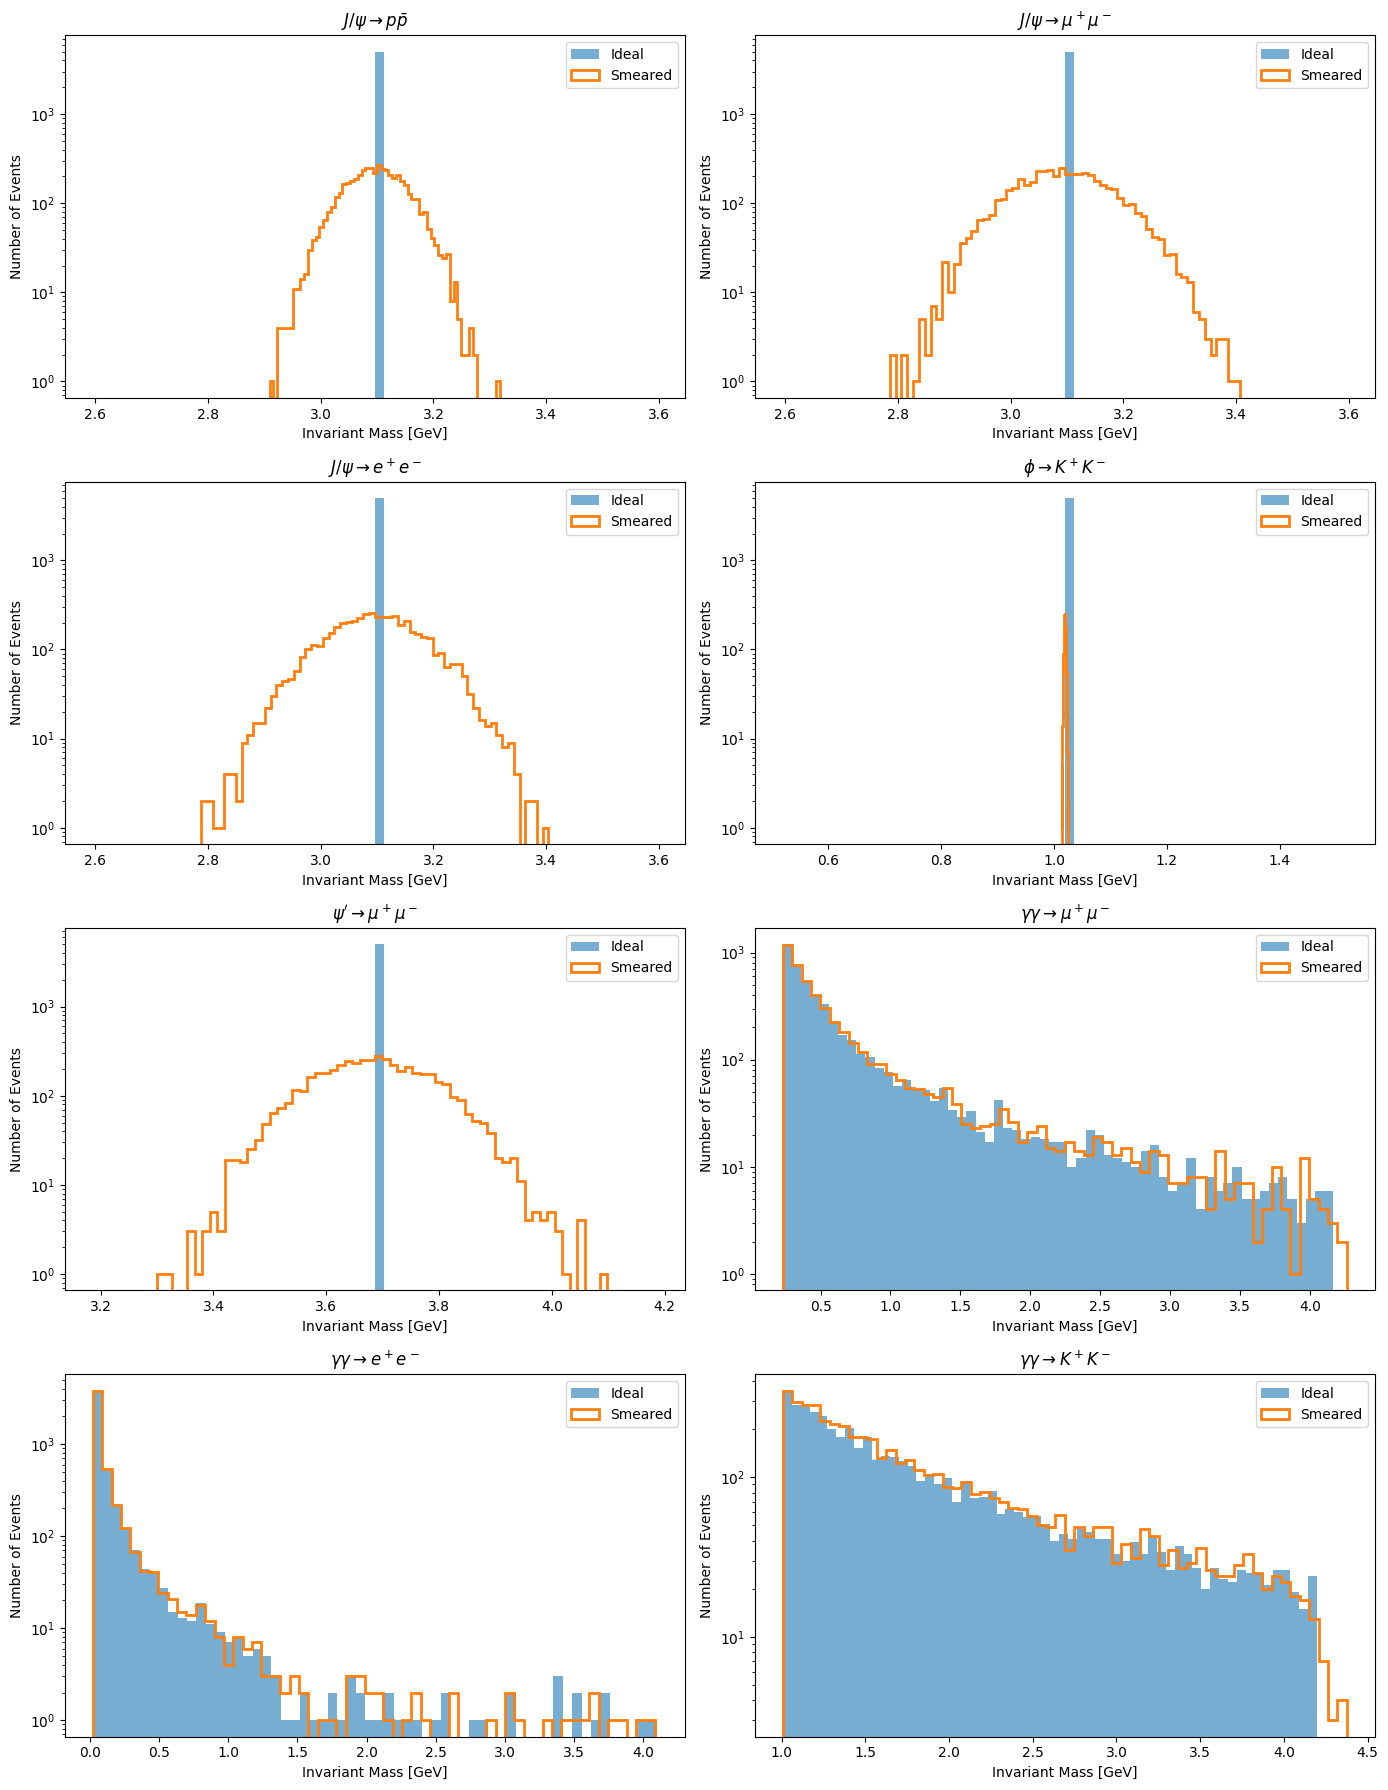

In [19]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# =====================================================
# PARTICLE MASSES [GeV]
# =====================================================
masses_dict = {
    "p": 0.938,
    "mu": 0.105,
    "e": 0.000511,
    "K": 0.494
}

# =====================================================
# RESONANCES
# =====================================================
resonances = {
    "J/psi": 3.096,
    "phi": 1.019,
    "psi'": 3.686
}

# =====================================================
# FUNCTIONS
# =====================================================

def two_body_decay(M, m1, m2):
    term1 = M**2 - (m1 + m2)**2
    term2 = M**2 - (m1 - m2)**2
    p = np.sqrt(term1 * term2) / (2 * M)

    cos_theta = np.random.uniform(-1, 1)
    phi = np.random.uniform(0, 2*np.pi)

    sin_theta = np.sqrt(1 - cos_theta**2)

    px = p * sin_theta * np.cos(phi)
    py = p * sin_theta * np.sin(phi)
    pz = p * cos_theta

    p1 = np.array([px, py, pz])
    p2 = -p1

    E1 = np.sqrt(p**2 + m1**2)
    E2 = np.sqrt(p**2 + m2**2)

    return (E1, p1), (E2, p2)


def invariant_mass(E1, p1, E2, p2):
    E = E1 + E2
    p = p1 + p2
    return np.sqrt(E**2 - np.dot(p, p))


def smear_vector(pvec, resolution=0.04):
    factor = np.random.normal(1.0, resolution)
    return pvec * factor


# =====================================================
# REALISTIC gamma-gamma MASS SPECTRUM ~ 1/M^2
# =====================================================

def sample_gamma_gamma_mass(mmin, mmax):
    while True:
        M = np.random.uniform(mmin, mmax)
        y = np.random.uniform(0, 1)

        # normalized weight
        weight = (mmin / M)**2

        if y < weight:
            return M


# =====================================================
# PROCESSES
# =====================================================

processes = {
    r"$J/\psi \to p\bar{p}$": ("resonance", "J/psi", "p", "p"),
    r"$J/\psi \to \mu^+\mu^-$": ("resonance", "J/psi", "mu", "mu"),
    r"$J/\psi \to e^+e^-$": ("resonance", "J/psi", "e", "e"),
    r"$\phi \to K^+K^-$": ("resonance", "phi", "K", "K"),
    r"$\psi' \to \mu^+\mu^-$": ("resonance", "psi'", "mu", "mu"),

    r"$\gamma\gamma \to \mu^+\mu^-$": ("continuum", None, "mu", "mu"),
    r"$\gamma\gamma \to e^+e^-$": ("continuum", None, "e", "e"),
    r"$\gamma\gamma \to K^+K^-$": ("continuum", None, "K", "K"),
}

# =====================================================
# EVENT GENERATION
# =====================================================

N = 5000

results_true = {}
results_smear = {}

for name, cfg in processes.items():

    mode, resonance, p1_name, p2_name = cfg

    m1 = masses_dict[p1_name]
    m2 = masses_dict[p2_name]

    masses_true = []
    masses_s = []

    for _ in range(N):

        # Resonance
        if mode == "resonance":
            M = resonances[resonance]

        # Realistic gamma-gamma continuum
        else:
            M = sample_gamma_gamma_mass(m1 + m2 + 0.02, 4.2)

        (E1, p1), (E2, p2) = two_body_decay(M, m1, m2)

        m_true = invariant_mass(E1, p1, E2, p2)

        p1s = smear_vector(p1)
        p2s = smear_vector(p2)

        E1s = np.sqrt(np.dot(p1s, p1s) + m1**2)
        E2s = np.sqrt(np.dot(p2s, p2s) + m2**2)

        m_s = invariant_mass(E1s, p1s, E2s, p2s)

        masses_true.append(m_true)
        masses_s.append(m_s)

    results_true[name] = masses_true
    results_smear[name] = masses_s

# =====================================================
# PLOTS
# =====================================================

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, name in enumerate(processes.keys()):

    ax = axes[i]

    ax.hist(results_true[name],
            bins=60,
            alpha=0.6,
            label="Ideal")

    ax.hist(results_smear[name],
            bins=60,
            histtype="step",
            linewidth=2,
            label="Smeared")

    ax.set_yscale("log")

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Invariant Mass [GeV]")
    ax.set_ylabel("Number of Events")
    ax.legend()

plt.tight_layout()
plt.show()